# CMSE 402 Homework02
### Mikel Good
### 3/19/2026

In [26]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import plotly.express as px
import pycountry

In [2]:
# data
death_data = pd.read_csv("data_files/leading_cause_death.csv")
pop_data = pd.read_csv("data_files/Population by Select AgeMichigan Population.csv")
human_dev = pd.read_csv("data_files/human_development.csv")
ghg = pd.read_excel("data_files/EDGAR_AR5_GHG_1970_2023.xlsx",
                    sheet_name="TOTALS BY COUNTRY", skiprows=9)
ch4 = pd.read_excel("data_files/EDGAR_CH4_1970_2023.xlsx",
                   sheet_name="TOTALS BY COUNTRY", skiprows=9)
co2 = pd.read_excel("data_files/IEA_EDGAR_CO2_1970_2023.xlsx",
                   sheet_name="TOTALS BY COUNTRY", skiprows=9)
n2o = pd.read_excel("data_files/EDGAR_N2O_1970_2023.xlsx",
                   sheet_name="TOTALS BY COUNTRY", skiprows=9)
ghg_ip = pd.read_excel("data_files/EDGAR_AR5_GHG_1970_2023.xlsx",
                       sheet_name="IPCC 2006", skiprows=9)

## Part 1

In [3]:
# additional data cleaning
mi_death = death_data[death_data["STATE"] == "Michigan"]
mi_death_suic = mi_death[mi_death["CAUSE_NAME"] == "Suicide"]
mi_death_suic["DEATHS"] = mi_death_suic["DEATHS"].astype(int)
mi_death_suic = mi_death_suic[mi_death_suic["YEAR"] != 1999] # drop 1999 to match pop_data

pop_data = pop_data.drop([5, 16, 27])
pop_data["Year"] = pop_data["Year"].astype(int)
pop_data["TotalPopulation"] = pop_data["TotalPopulation"].str.replace(",", "")
pop_data["TotalPopulation"] = pop_data["TotalPopulation"].astype(int)
pop_data = pop_data[pop_data["Year"] <= 2013]
pop_data.head()

/tmp/ipykernel_202216/1221878705.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mi_death_suic["DEATHS"] = mi_death_suic["DEATHS"].astype(int)


,Year,TotalPopulation,YearlyChange (%),Number,Percentof TotalPopulation
12,2013,9914802,0.17,"1,487,694",15.00
13,2012,9898289,0.15,"1,443,150",14.58
14,2011,9883053,0.06,"1,388,638",14.05
15,2010,9877597,-0.24,"1,366,274",13.83
17,2009,9901591,-0.46,"1,343,623",13.57


In [4]:
normalized = []

for i in range(len(mi_death_suic)):
    death_tot = mi_death_suic.iloc[i]["DEATHS"]
    pop_tot = pop_data.iloc[i]["TotalPopulation"]
    normalized.append(death_tot/pop_tot * 1e5)

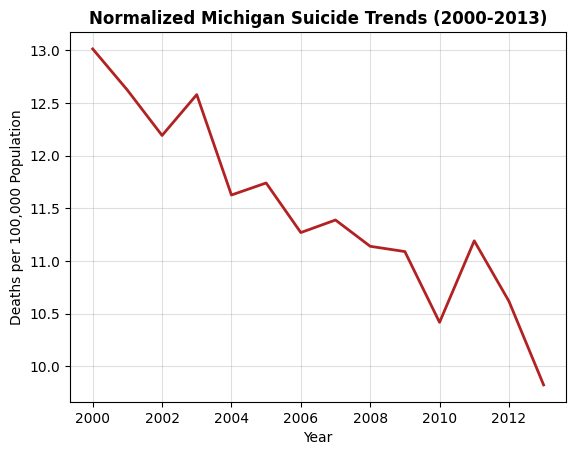

In [27]:
plt.plot(pop_data["Year"], normalized, color="firebrick", lw=2)
plt.xlabel("Year")
plt.ylabel("Deaths per 100,000 Population")
plt.title("Normalized Michigan Suicide Trends (2000-2013)", fontweight="bold")
plt.grid(alpha=0.4)
plt.savefig("viz_files/Part1_revised.png", dpi=400)
plt.show()

### Write up
When peer-reviewing my visualization that I created initially, a number of beneficial constructive comments were given. I was intending on displaying the Michigan suicide trends in the last couple of decades, however the way that I communicated this message wasn't the best. For starters, at first I created a bar chart, and my group instead suggested that the trend would be easier to visualize using a line chart. Additionally, to accommodate for the varying population values, they also recommended that I normalize my data. I implemented both of these changes, and I believe it resulted in a much more communicative graphic. It took a little bit of extra work because I had to get an additional data set that carried total population information for Michigan, clean the data, and normalize the values, but it was well worth the extra effort. One of the main reasons that a bar chart was discouraged by my team was due to the large values (~ 1000) that made the small changes hard to visualize. Observing this newly created chart addresses that issue, and the trends that once looked indistinct are now quite visible. This difficulty has also been aided by the incorporation of the normalization. Overall, in combined with the readings from class, my interview with a professional, and the advice of my peers, I was able to alter my visualization in a way that makes it easier to view.

## Part 2

In [6]:
human_dev["Gross National Income (GNI) per Capita"] = human_dev["Gross National Income (GNI) per Capita"].str.replace(",", "")
human_dev["Gross National Income (GNI) per Capita"] = human_dev["Gross National Income (GNI) per Capita"].astype(int)

In [7]:
def get_iso3(country_name):
    try:
        return pycountry.countries.lookup(country_name).alpha_3
    except:
        return None

human_dev["iso3"] = human_dev["Country"].apply(get_iso3)

In [8]:
human_dev.head()

,HDI Rank,Country,Human Development Index (HDI),Life Expectancy at Birth,Expected Years of Education,Mean Years of Education,Gross National Income (GNI) per Capita,GNI per Capita Rank Minus HDI Rank,iso3
0,1.0,Norway,0.944,81.6,17.5,12.6,64992,5.0,NOR
1,2.0,Australia,0.935,82.4,20.2,13.0,42261,17.0,AUS
2,3.0,Switzerland,0.930,83.0,15.8,12.8,56431,6.0,CHE
3,4.0,Denmark,0.923,80.2,18.7,12.7,44025,11.0,DNK
4,5.0,Netherlands,0.922,81.6,17.9,11.9,45435,9.0,NLD


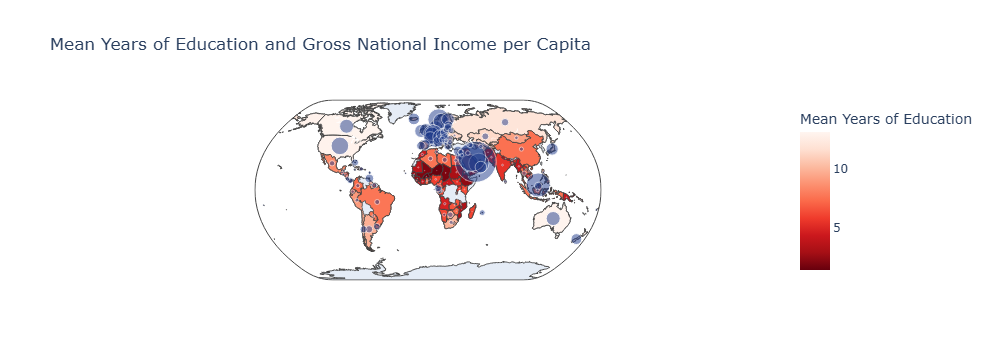

In [29]:
fig = px.choropleth(
    human_dev,
    locations="iso3",
    color="Mean Years of Education",
    projection="natural earth",
    title="Mean Years of Education and Gross National Income per Capita",
    hover_data=["HDI Rank", "Mean Years of Education", "Gross National Income (GNI) per Capita"],
    color_continuous_scale="Reds_r",
    
)

fig.add_scattergeo(
    locations=human_dev["iso3"],
    text=human_dev["Country"],
    marker=dict(
        size=human_dev["Gross National Income (GNI) per Capita"] / 3000,
        color="#1e3a8a", #trying to choose a color that doesn't interfere with the choropleth
        opacity=0.5
    ),
    hoverinfo="text"
)

fig.write_html("viz_files/Part2.html", include_plotlyjs="cdn")
fig.show()

### Write up
Although I have already seen similar graphics to the one that I have created above, I thought it would be a good way to visualize this world wide human development index data. While it takes a little while to read the figure due to the slightly complex nature, I think part of this is intrinsic to multi-dimensional data. In this data visualization, I initially was going to use the viridis color map to incorporate some of the new material we learned about color theory and making visuals that are able to be interpreted by people that have color vision deficiency, however I decided against this to incorporate some of the aspects of data visceralization/data feminism. To highlight the educational disparities that plague lower developed companies, I choose a dark red to invoke emotion when looking at the visual. This stands out tremendously when viewing the lighter countries, and definitely enhances the viewing experience. The motivation behind me creating this figure was to observe the correlation between education and gross national income per capita. As shown in the graphic, there is a high correlation between these two attributes. While I've created a choropleth visualization before, this is the first time I've every created a plot that superposed another layer to the map, so referencing the plotly documentation came in handy. This plot is advantageous over other plots because it lets you see two very correlated variables at once on a map. In my experience with data visualizations, I only primarily see choropleths in one dimensional form, so it adds to the conclusions that can be gleaned from the figure. At the same time, it adds a little bit to the clutter of the graphic, so it might go against some of the principles that Tufte tends to follow, however his opinions on data visualizations follow a very strict code. <br> <br>

**Wickham's Grammar of Graphics**
* Data: mean years of education, HDI rank, GNI per capita.
* Aesthetics: fill color (mean years of education), geographic position (location/country code), scatter points (GNI per capita), hover text (HDI rank, mean years of education, GNI per capita)
* Geometry: country polygons
* Scales: A red continuum scale, accompanied with a color bar for a legend
* Coordinate system: the map/earth
* Guides: title, color bar legend, ability to hover

## Part 3

In [10]:
# Top left graph computations
nan_idxs = ghg.index[ghg.isna().any(axis=1)].tolist()
ghg = ghg.drop(index=nan_idxs)
top5 = ghg.nlargest(5, "Y_2023")
top5_frac = []
for year in range(1970, 2024):
    col = "Y_" + str(year)
    tot = ghg[col].sum()
    dic = {}
    for country in top5["Name"]:
        temp = top5[top5["Name"] == country]
        frac = temp[col].iloc[0]/tot
        dic[country] = frac

    top5_frac.append(dic)

top5_df = pd.DataFrame(top5_frac).T
top5_df.columns = list(range(1970, 2024))
top5_df

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
China,0.084786,0.086829,0.086647,0.084232,0.085093,0.092003,0.090424,0.094307,0.098517,0.097632,...,0.271723,0.268781,0.267144,0.267895,0.273497,0.278392,0.293910,0.294281,0.291707,0.301040
United States,0.241165,0.235423,0.237503,0.234060,0.227217,0.218743,0.221179,0.221482,0.215823,0.212985,...,0.131786,0.129669,0.126508,0.123334,0.124197,0.121151,0.114978,0.116305,0.116344,0.112546
India,0.033030,0.033133,0.032327,0.031110,0.031931,0.033084,0.032538,0.032429,0.031749,0.031936,...,0.066837,0.067662,0.068401,0.070138,0.071764,0.071032,0.069608,0.071359,0.074992,0.078046
Russian Federation,0.071790,0.072268,0.072925,0.073424,0.076925,0.080635,0.080091,0.079914,0.082718,0.081943,...,0.045834,0.046255,0.045801,0.046075,0.047063,0.048419,0.048565,0.049409,0.050444,0.050451
Brazil,0.014557,0.014861,0.015142,0.015489,0.016546,0.017402,0.018036,0.018235,0.018317,0.018680,...,0.025917,0.025657,0.025028,0.024841,0.023832,0.023799,0.024651,0.025103,0.024986,0.024549


In [11]:
# Top right graph computations
log_2023 = np.log10(ghg["Y_2023"])

In [12]:
# Bottom left graph computations
emis = []
for year in range(1970, 2024):
    col = "Y_" + str(year)
    ch4_tot = ch4[col].sum() * 28 # GWP scale
    n2o_tot = n2o[col].sum() * 265 # GWP scale
    co2_tot = co2[col].sum()

    emis.append({"CH4": ch4_tot, "N2O": n2o_tot, "CO2": co2_tot})

emis_df = pd.DataFrame(emis).T
emis_df.columns = range(1970, 2024)
emis_df

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
CH4,6.526156e+06,6.612139e+06,6.699511e+06,6.865661e+06,6.896520e+06,6.959134e+06,7.037915e+06,7.097819e+06,7.126177e+06,7.229768e+06,...,8.958403e+06,8.985199e+06,9.039981e+06,9.163432e+06,9.305140e+06,9.380830e+06,9.297843e+06,9.475260e+06,9.661036e+06,9.788188e+06
N2O,1.443523e+06,1.464173e+06,1.490442e+06,1.537061e+06,1.558984e+06,1.582190e+06,1.629173e+06,1.663030e+06,1.708966e+06,1.734783e+06,...,2.312136e+06,2.328422e+06,2.352679e+06,2.362454e+06,2.375511e+06,2.407162e+06,2.411782e+06,2.440756e+06,2.460588e+06,2.486955e+06
CO2,1.575186e+07,1.568339e+07,1.648144e+07,1.746439e+07,1.740028e+07,1.732856e+07,1.831701e+07,1.887171e+07,1.949123e+07,2.003186e+07,...,3.642779e+07,3.630049e+07,3.642368e+07,3.704748e+07,3.797457e+07,3.806645e+07,3.615432e+07,3.812103e+07,3.824664e+07,3.902395e+07


In [14]:
# Bottom right graph computations
ghg_ip_us = ghg_ip[ghg_ip["Name"] == "United States"]
ghg_ip_us = ghg_ip_us.dropna(subset="Y_2013")
by_sector = {}
sector_code = {1: "Energy", 2: "Industrial", 3: "Agriculture",
               4: "Land Use", 5: "Waste"}

for _, row in ghg_ip_us.iterrows():
    code = int(row["ipcc_code_2006_for_standard_report"][0])
    sector = sector_code[code]
    amount = row["Y_2023"]

    if type(amount) == float:
        if sector not in by_sector:
            by_sector[sector] = amount
        else:
            by_sector[sector] += amount

by_sector_sorted = np.array(sorted(by_sector.items(), key=lambda x: x[1], reverse=True))

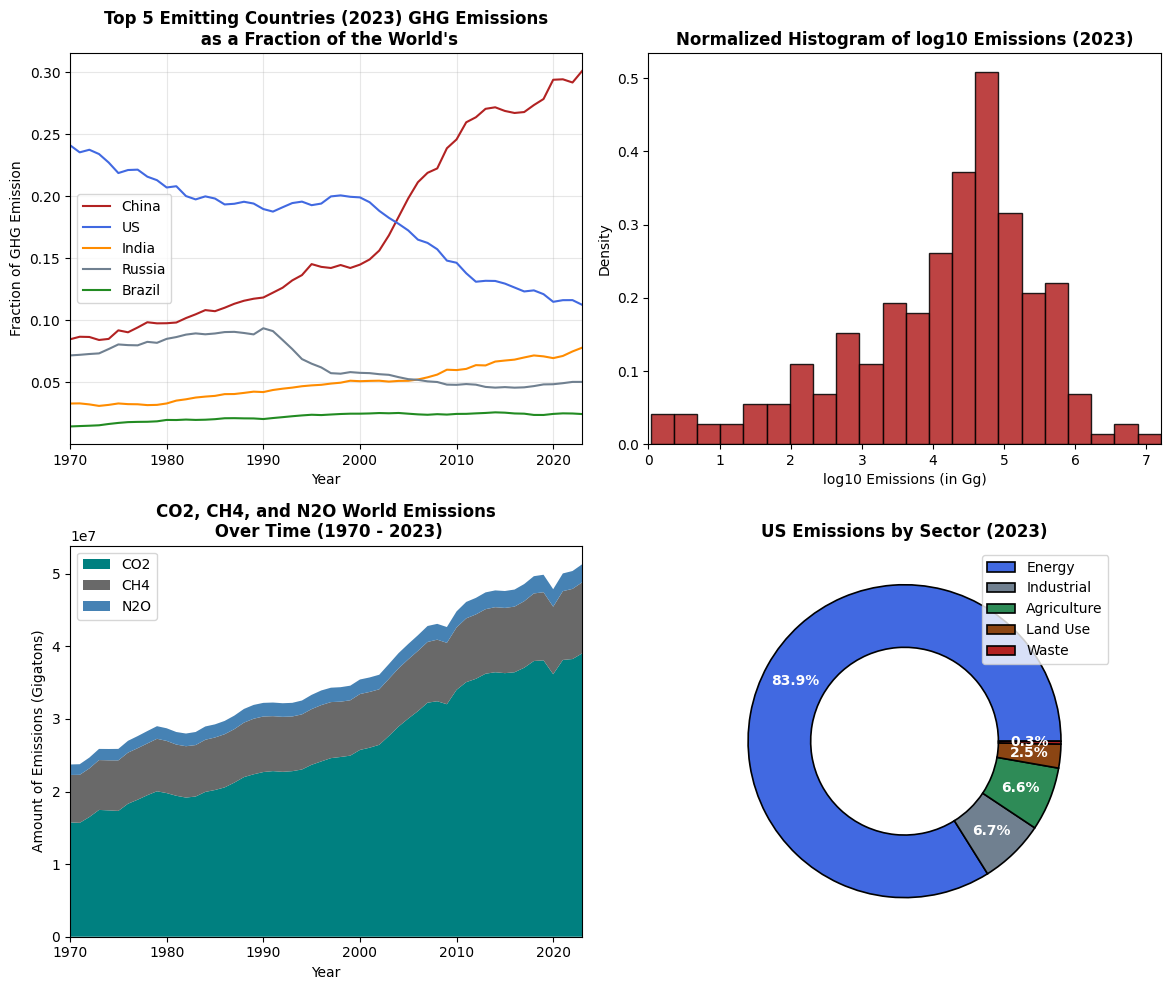

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Top left graph
axes[0,0].plot(list(top5_df.columns), top5_df.loc["China"], label="China", color="firebrick")
axes[0,0].plot(list(top5_df.columns), top5_df.loc["United States"], label="US", color="royalblue")
axes[0,0].plot(list(top5_df.columns), top5_df.loc["India"], label="India", color="darkorange")
axes[0,0].plot(list(top5_df.columns), top5_df.loc["Russian Federation"], label="Russia", color="slategray")
axes[0,0].plot(list(top5_df.columns), top5_df.loc["Brazil"], label="Brazil", color="forestgreen")
axes[0,0].legend()
axes[0,0].set_title("Top 5 Emitting Countries (2023) GHG Emissions\n as a Fraction of the World's",
                   fontweight="bold")
axes[0,0].set_xlabel("Year")
axes[0,0].set_ylabel("Fraction of GHG Emission")
axes[0,0].set_xlim(1970, 2023)
axes[0,0].grid(True, alpha=0.3)

# Top right graph
axes[0,1].hist(log_2023, bins=22, density=True, color="firebrick", alpha=0.85, edgecolor="black")
axes[0,1].set_title("Normalized Histogram of log10 Emissions (2023)", fontweight="bold")
axes[0,1].set_xlabel("log10 Emissions (in Gg)")
axes[0,1].set_ylabel("Density")
axes[0,1].set_xlim(0, 7.2)

# Bottom left graph
axes[1,0].stackplot(emis_df.columns, emis_df.loc["CO2"], emis_df.loc["CH4"], emis_df.loc["N2O"],
                    labels=["CO2", "CH4", "N2O"], colors=["teal", "dimgray", "steelblue"])
axes[1,0].set_title("CO2, CH4, and N2O World Emissions\n Over Time (1970 - 2023)", fontweight="bold")
axes[1,0].set_xlabel("Year")
axes[1,0].set_ylabel("Amount of Emissions (Gigatons)")
axes[1,0].legend()
axes[1,0].set_xlim(1970, 2023)

# Bottom right graph
axes[1,1].pie(by_sector_sorted[:, 1], labels=by_sector_sorted[:, 0],
             colors=["royalblue", "slategray", "seagreen", "saddlebrown", "firebrick"],
             wedgeprops={"width": 0.4, "edgecolor": "black", "linewidth": 1.2},
             autopct="%1.1f%%", pctdistance=0.8, textprops={"color": "white", "fontweight": "bold"})
axes[1,1].set_title("US Emissions by Sector (2023)", fontweight="bold")
axes[1,1].legend(bbox_to_anchor=(0.68, 0.68))

plt.tight_layout()
plt.savefig("viz_files/Part3.png", dpi=400)
plt.show()

### Write Up
For this visualization, I did not get to choose the physical graph that I was constructing, rather I was limited to more minor, but still important, aspects, such as color, font size, and overall layout. Because of this, I had to focus on how the items that I was able to control could be manipulated in a way such that the information I wanted to display stood out and is eye-catching to potential viewers. However, when constructing this figure, I was still able to implement concepts that we have learned from class up to this point. In chapter 8 of his book, Alberto Cairo states that how you plot your data depends on what you want to emphasize, and that it is important to plot data in many ways to get a well-rounded view of what is taking place. That is exactly what is being implemented in the multi-panel graphic above. Using a combination of line charts, histograms, area charts, and donut charts allows for an encapsulated view of the data. Additionally, the techniques mentioned in the "Data Feminism" reading by Catherine D'Ignazio and Lauren Klein were put in practice through the choice of color, font size, and layout. In this reading, the authors emphasize utilizing a combination of reason and emotion when creating graphics. By presenting the data in an truthful and accurate manner, while also appealing to the viewer's emotion, one is able to create an intriguing visualization. In my plots, I did this primarily through my color choice. For example, in the line chart, I used colors that are commonly corresponded with their respective countries, making it easier to interpret for the reader. If I were to create an additional graphic to replace one of the panels above, I would choose to make a bar chart instead of the donut chart. Since the histogram already incorporates some of the aspects of a vertical bar chart, I would likely choose to make it horizontal to keep the distinctness of each panel. I would choose this alternative because of how humans interpret the fractional area in a circle compared to the straight lines of a bar chart. In the words of Alberto Cairo (Chapter 6), "I'd go with length, height, or position, and here's why: if you don’t know what the numbers are before you see the rest of the charts, the ones based on area, angle, weight, and color, can you quickly identify the highest or lowest unemployment rates and accurately compare them to the others? It’s hard, isn’t it?" So, since the goal of this visualization is to compare the emissions by sector, a bar chart would accomplish this much better. The only reason it's not the end of the world in this case is because the energy section dominates all the others, so you can quickly identify which sector is dominating the emissions (and the percentages of each category are included). <br> <br>

**Wickham's Grammar of Graphics**
1. Data
   * Top-left: yearly emissions as a fraction of the world's total emissions for the top five countries
   * Top-right: yearly global emissions histogram distribution with a log base 10 scale
   * Bottom-left: yearly CO2, CH4, N2O totals
   * U.S. emissions broken down by sector for each specific year
2. Aesthetic mappings
   * Top-left: the x variable represents the year, the y represents the fraction of the world emissions, and the color corresponds to the country
   * Top right: the x variable corresponds to the log base 10 of the emissions and the y represents density
   * Bottom-left: the x variable represents the year, the y represents the gas amount, and the fill corresponds to the individual gas
   * Bottom-right: the x variable corresponds to the sector and the y variable corresponds to the percentage of emissions from each sector
3. Geometry
   * Top-left: lines are used
   * Top-right: rectangles/boxes are used
   * Bottom-left: a filled area underneath a line is used
   * Bottom-right: a filled circle/donut is used
4. Scales:
   * For the two time series charts (on the left) the x scales are from 1970-2023. The y scale depend on each graphic, and it consists of a scale from zero to a maximum of one (top-left, although realistically the max only gets to ~ 0.3 and top-right [log 10 scale], although realistically the max only gets to ~ 0.5). The other scale used is color, which relates the countries, gases, and sectors for each individual plot to the data that they map to.
5. Coordinate system
   * Cartesian coordinates for the line plot, histogram, and area chart
   * No real "coordinate system" for the donut chart, just a circle
6. Faceting
   * The visualization consists of four panels, which each represent a different part of the data. Because of this, you are able to see the data and trends from many different perspectives, all in one graphic. 

## Part 4

In [16]:
def donut_comps(year):
    col = "Y_" + str(year)
    ghg_ip_us = ghg_ip[ghg_ip["Name"] == "United States"]
    by_sector = {}
    sector_code = {1: "Energy", 2: "Industrial", 3: "Agriculture",
                   4: "Land Use", 5: "Waste"}
    
    for _, row in ghg_ip_us.iterrows():
        code = int(row["ipcc_code_2006_for_standard_report"][0])
        sector = sector_code[code]
        amount = row[col]
    
        if not pd.isna(amount):
            if sector not in by_sector:
                by_sector[sector] = amount
            else:
                by_sector[sector] += amount
    
    by_sector_sorted = np.array(sorted(by_sector.items(), key=lambda x: x[1], reverse=True))
    return by_sector_sorted

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i in range(0, 2024-1970):
    year = i + 1970

    # Top left graph
    axes[0,0].plot(list(top5_df.columns)[:i], top5_df.loc["China"].iloc[:i],
                   label="China", color="firebrick")
    axes[0,0].plot(list(top5_df.columns)[:i], top5_df.loc["United States"].iloc[:i],
                   label="US", color="royalblue")
    axes[0,0].plot(list(top5_df.columns)[:i], top5_df.loc["India"].iloc[:i],
                   label="India", color="darkorange")
    axes[0,0].plot(list(top5_df.columns)[:i], top5_df.loc["Russian Federation"].iloc[:i],
                   label="Russia", color="slategray")
    axes[0,0].plot(list(top5_df.columns)[:i], top5_df.loc["Brazil"].iloc[:i],
                   label="Brazil", color="forestgreen")
    axes[0,0].legend()
    axes[0,0].set_title("Top 5 Emitting Countries ({}) GHG Emissions\n as a Fraction of the World's".format(year),
                       fontweight="bold")
    axes[0,0].set_xlabel("Year")
    axes[0,0].set_ylabel("Fraction of GHG Emission")
    axes[0,0].set_xlim(1970, 2023)
    axes[0,0].set_ylim(0, np.max(top5_df.max()) + 0.05)
    axes[0,0].grid(True, alpha=0.3)

    # Top right graph
    col = "Y_" + str(year)
    log_update = np.log10(ghg[col])
    axes[0,1].hist(log_update, bins=22, density=True, color="firebrick", alpha=0.85, edgecolor="black")
    axes[0,1].set_title("Normalized Histogram of log10 Emissions (2023)", fontweight="bold")
    axes[0,1].set_xlabel("log10 Emissions (in Gg)")
    axes[0,1].set_ylabel("Density")
    axes[0,1].set_ylim(0, 0.6)

    # Bottom left graph
    axes[1,0].stackplot(list(emis_df.columns)[:i], emis_df.loc["CO2"].iloc[:i], emis_df.loc["CH4"].iloc[:i],
                        emis_df.loc["N2O"].iloc[:i], labels=["CO2", "CH4", "N2O"], 
                        colors=["teal", "dimgray", "steelblue"])
    axes[1,0].set_title("CO2, CH4, and N2O World Emissions\n Over Time (1970 - 2023)", fontweight="bold")
    axes[1,0].set_xlabel("Year")
    axes[1,0].set_ylabel("Amount of Emissions (Gigatons)")
    axes[1,0].legend()
    axes[1,0].set_xlim(1970, 2023)
    axes[1,0].set_ylim(0, 5.5e7)

    # Bottom right graph
    by_sector_sorted = donut_comps(year)
    axes[1,1].pie(by_sector_sorted[:, 1], labels=by_sector_sorted[:, 0],
                 colors=["royalblue", "slategray", "seagreen", "saddlebrown", "firebrick"],
                 wedgeprops={"width": 0.4, "edgecolor": "black", "linewidth": 1.2},
                 autopct="%1.1f%%", pctdistance=0.8, textprops={"color": "white", "fontweight": "bold"})
    axes[1,1].set_title("US Emissions by Sector ({})".format(year), fontweight="bold")
    axes[1,1].legend(bbox_to_anchor=(0.68,0.68))

    filename = "image_{:03d}.png".format(i)
    path = "animation_files/" + filename

    plt.tight_layout()
    fig.savefig(path, dpi=400)
    axes[0,0].cla()
    axes[0,1].cla()
    axes[1,0].cla()
    axes[1,1].cla()
    plt.close(fig)

<Figure size 640x480 with 0 Axes>

### Terminal Command Used
```text
ffmpeg -framerate 3 -i animation_files/image_%03d.png -pix_fmt yuv420p viz_files/Part4.mp4
```

### Write Up
For this visualization, I did not get to choose the physical graph that I was constructing, rather I was limited to more minor, but still important, aspects, such as color, font size, and overall layout. Because of this, I had to focus on how the items that I was able to control could be manipulated in a way such that the information I wanted to display stood out and is eye-catching to potential viewers. However, when constructing an animation like the one in the figure, it emphasizes displaying the change over time, which follows the techniques that we learned from Chapter 8 of "The Truthful Art - Data, Charts, and Maps for Communication" by Alberto Cairo. In this chapter, he states that how you plot your data depends on what you want to emphasize, and that it is important to plot data in many ways to get a well-rounded view of what is taking place. That is exactly what is being implemented in the multi-panel graphic above. Using a combination of line charts, histograms, area charts, and donut charts allows for an encapsulated view of the data and how it varies throughout the time frame that is being examined. Additionally, the techniques mentioned in the "Data Feminism" reading by Catherine D'Ignazio and Lauren Klein were put in practice through the choice of color, font size, and layout. In this reading, the authors emphasize utilizing a combination of reason and emotion when creating graphics. By presenting the data in an truthful and accurate manner, while also appealing to the viewer's emotion, one is able to create an intriguing visualization. In my plots, I did this primarily through my color choice. For example, in the line chart, I used colors that are commonly corresponded with their respective countries, making it easier to interpret for the reader. <br> <br>

**Wickham's Grammar of Graphics**
1. Data
   * Top-left: yearly emissions as a fraction of the world's total emissions for the top five countries
   * Top-right: yearly global emissions histogram distribution with a log base 10 scale
   * Bottom-left: yearly CO2, CH4, N2O totals
   * U.S. emissions broken down by sector for each specific year
2. Aesthetic mappings
   * Top-left: the x variable represents the year, the y represents the fraction of the world emissions, and the color corresponds to the country
   * Top right: the x variable corresponds to the log base 10 of the emissions and the y represents density
   * Bottom-left: the x variable represents the year, the y represents the gas amount, and the fill corresponds to the individual gas
   * Bottom-right: the x variable corresponds to the sector and the y variable corresponds to the percentage of emissions from each sector
3. Geometry
   * Top-left: lines are used
   * Top-right: rectangles/boxes are used
   * Bottom-left: a filled area underneath a line is used
   * Bottom-right: a filled circle/donut is used
4. Scales:
   * For the two time series charts (on the left) the x scales are from 1970-2023. The y scale depend on each graphic, and it consists of a scale from zero to a maximum of one (top-left, although realistically the max only gets to ~ 0.3 and top-right [log 10 scale], although realistically the max only gets to ~ 0.5). The other scale used is color, which relates the countries, gases, and sectors for each individual plot to the data that they map to.
5. Coordinate system
   * Cartesian coordinates for the line plot, histogram, and area chart
   * No real "coordinate system" for the donut chart, just a circle
6. Faceting
   * The visualization consists of four panels, which each represent a different part of the data. Because of this, you are able to see the data and trends from many different perspectives, all in one graphic. 